In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/DataScience75/Top_mentor_projects_Datasets/refs/heads/main/9.2%20car-sales-missing-data.csv"

In [3]:
data = pd.read_csv(url)
print(data.head(2))

     Make Colour  Odometer  Doors   Price
0  Toyota  White  150043.0    4.0  $4,000
1   Honda    Red   87899.0    4.0  $5,000


In [113]:
### create a copy of the data
df = data.copy()
print(df)

     Make Colour  Odometer  Doors    Price
0  Toyota  White  150043.0    4.0   $4,000
1   Honda    Red   87899.0    4.0   $5,000
2  Toyota   Blue       NaN    3.0   $7,000
3     BMW  Black   11179.0    5.0  $22,000
4  Nissan  White  213095.0    4.0   $3,500
5  Toyota  Green       NaN    4.0   $4,500
6   Honda    NaN       NaN    4.0   $7,500
7   Honda   Blue       NaN    4.0      NaN
8  Toyota  White   60000.0    NaN      NaN
9     NaN  White   31600.0    4.0   $9,700


In [5]:
print("Missing values - ")
print(df.isnull().sum())

Missing values - 
Make        1
Colour      1
Odometer    4
Doors       1
Price       2
dtype: int64


In [11]:
df.shape

(10, 5)

In [7]:
#### Calculate the Percentage Missing - 
#### (Number of Missing Values / Total Number of Values)*100
total_values = df.shape[0]  ### total number of rows
missing_percent = (df.isnull().sum() / total_values)*100
print(missing_percent)

Make        10.0
Colour      10.0
Odometer    40.0
Doors       10.0
Price       20.0
dtype: float64


In [32]:
missing_percent[missing_percent < 20]

Make      10.0
Colour    10.0
Doors     10.0
dtype: float64

In [14]:
#### How to impute the Missing records 15-20%
### 1st Method - Drop
df.dropna()

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [18]:
df.dropna(axis = 0, how = 'any')  ### Drop the columns (1) or rows (0) have any NaN values
### axis = 1 it is for columns , axis = 0 for rows

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [45]:
df.dropna(axis = 0, thresh = len(df)*0.2) # 40 % Missing, more than 40% will be dropeed

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [34]:
### Droppping based on Percentage -- 
df.dropna(subset = ['Make','Colour','Doors'])

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
7,Honda,Blue,NaN,4.0,NaN


In [48]:
df[['Odometer','Doors']].mean()

Odometer    92302.666667
Doors           4.000000
dtype: float64

In [37]:
#### Filling the records ---
df[['Odometer','Doors', 'Price']].fillna(0)

,Odometer,Doors,Price
0,150043.0,4.0,"$4,000"
1,87899.0,4.0,"$5,000"
2,0.0,3.0,"$7,000"
3,11179.0,5.0,"$22,000"
4,213095.0,4.0,"$3,500"
5,0.0,4.0,"$4,500"
6,0.0,4.0,"$7,500"
7,0.0,4.0,0
8,60000.0,0.0,0
9,31600.0,4.0,"$9,700"


In [69]:
df['Price'] = pd.to_numeric(df['Price'].replace('[$,]','',regex = True))
df['Price'].dtypes

dtype('float64')

In [64]:
price_mean = df['Price'].mean()  #### Average of Price
doors_mean = df['Doors'].mean()

In [65]:
price_mean

np.float64(7900.0)

In [66]:
doors_mean

np.float64(4.0)

In [72]:
df['Price'] = df['Price'].fillna(price_mean)

In [73]:
df

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,4000.0
1,Honda,Red,87899.0,4.0,5000.0
2,Toyota,Blue,NaN,3.0,7000.0
3,BMW,Black,11179.0,5.0,22000.0
4,Nissan,White,213095.0,4.0,3500.0
5,Toyota,Green,NaN,4.0,4500.0
6,Honda,NaN,NaN,4.0,7500.0
7,Honda,Blue,NaN,4.0,7900.0
8,Toyota,White,60000.0,NaN,7900.0
9,NaN,White,31600.0,4.0,9700.0


In [79]:
### I want odometer to also replace by averge and doors by median
avg_odo = round(df['Odometer'].mean(),2)
print(avg_odo)
df['Odometer'] = df['Odometer'].fillna(avg_odo)

92302.67


In [82]:
doors_median = df['Doors'].median()
doors_median

np.float64(4.0)

In [84]:
df['Doors'] = df['Doors'].fillna(doors_median)

In [94]:
df['Make'].ffill()#.ffill()   ### Front fill

0    Toyota
1     Honda
2    Toyota
3       BMW
4    Nissan
5    Toyota
6     Honda
7     Honda
8    Toyota
9    Toyota
Name: Make, dtype: object

In [91]:
df['Colour'].bfill()   #### backfilling

0    White
1      Red
2     Blue
3    Black
4    White
5    Green
6     Blue
7     Blue
8    White
9    White
Name: Colour, dtype: object

In [111]:
df['Make'].value_counts()

Make
Toyota    4
Honda     3
BMW       1
Nissan    1
Name: count, dtype: int64

In [109]:
make_mode = df['Make'].mode()
mk = make_mode[0]
print(mk)

Toyota


In [110]:
df['Make'].fillna(mk)

0    Toyota
1     Honda
2    Toyota
3       BMW
4    Nissan
5    Toyota
6     Honda
7     Honda
8    Toyota
9    Toyota
Name: Make, dtype: object

In [ ]:
##### How to Impute Missing Values - 
# You can drop
# fill any value
# ffill, bfill
# replacing  - mean , median , mode
#### You have to decide  - Mostly numeric data  - mean, median
#### For categorical data  - we mostly use Mode

In [114]:
df

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [ ]:
#### I have a colour which is White and the price is Nan
### There are some prices for white  - 3500 + 9700 / 2 = 

In [3]:
##### Seaborn for graphs and Visaulisation ###
# !pip install seaborn
import seaborn as sns
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [4]:
### Read the car sales csv data
car_sales = pd.read_csv("https://raw.githubusercontent.com/DataScience75/Top_mentor_projects_Datasets/refs/heads/main/Car_sales.csv")
print(car_sales.head(2))

  Manufacturer    Model  Sales_in_thousands  __year_resale_value Vehicle_type  \
0        Acura  Integra              16.919               16.360    Passenger   
1        Acura       TL              39.384               19.875    Passenger   

   Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  Length  \
0                21.5          1.8       140.0      101.2   67.3   172.4   
1                28.4          3.2       225.0      108.1   70.3   192.9   

   Curb_weight  Fuel_capacity  Fuel_efficiency Latest_Launch  \
0        2.639           13.2             28.0    02-02-2012   
1        3.517           17.2             25.0    06-03-2011   

   Power_perf_factor  
0          58.280150  
1          91.370778  


In [6]:
(car_sales.isnull().sum() /car_sales.shape[0])*100

Manufacturer            0.000000
Model                   0.000000
Sales_in_thousands      0.000000
__year_resale_value    22.929936
Vehicle_type            0.000000
Price_in_thousands      1.273885
Engine_size             0.636943
Horsepower              0.636943
Wheelbase               0.636943
Width                   0.636943
Length                  0.636943
Curb_weight             1.273885
Fuel_capacity           0.636943
Fuel_efficiency         1.910828
Latest_Launch           0.000000
Power_perf_factor       1.273885
dtype: float64

In [7]:
cleaned_car_sales = car_sales.dropna()
cleaned_car_sales.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64

In [9]:
cleaned_car_sales.rename(columns = {'__year_resale_value':'Resale_value_year'}, inplace = True)  ### Permanently change in your dataframe

C:\Users\HP\AppData\Local\Temp\ipykernel_7332\2545103166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_car_sales.rename(columns = {'__year_resale_value':'Resale_value_year'}, inplace = True)  ### Permanently change in your dataframe


In [10]:
cleaned_car_sales.columns

Index(['Manufacturer', 'Model', 'Sales_in_thousands', 'Resale_value_year',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor'],
      dtype='object')

In [11]:
### Manufacturer wise Sales
cleaned_car_sales.groupby('Manufacturer')['Sales_in_thousands'].sum()

Manufacturer
Acura           64.891
Audi            40.557
BMW             26.758
Buick          242.019
Cadillac        81.450
Chevrolet      446.370
Chrysler       117.545
Dodge          720.798
Ford          1846.965
Honda          592.674
Hyundai        137.326
Infiniti        23.713
Jeep           293.153
Lexus           43.145
Lincoln         62.709
Mercedes-B      66.079
Mercury        237.999
Mitsubishi     180.895
Nissan         280.472
Oldsmobile      60.180
Plymouth        62.129
Pontiac        330.962
Porsche         12.128
Saturn         110.389
Toyota         675.086
Volkswagen     159.749
Name: Sales_in_thousands, dtype: float64

<Axes: xlabel='Sales_in_thousands', ylabel='Manufacturer'>

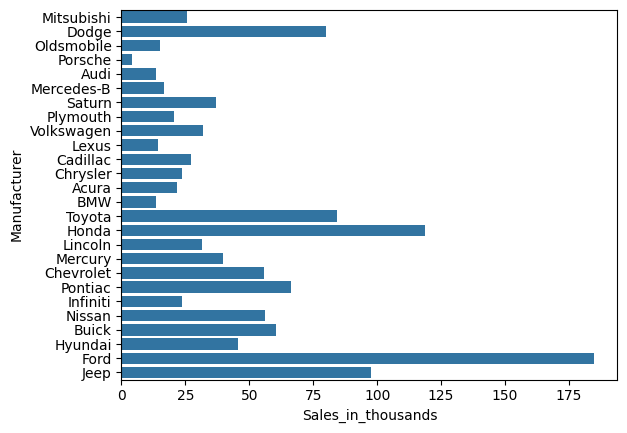

In [20]:
sns.barplot(y = 'Manufacturer', x = 'Sales_in_thousands', data = cleaned_car_sales,errorbar = None)

<Axes: xlabel='Sales_in_thousands', ylabel='Manufacturer'>

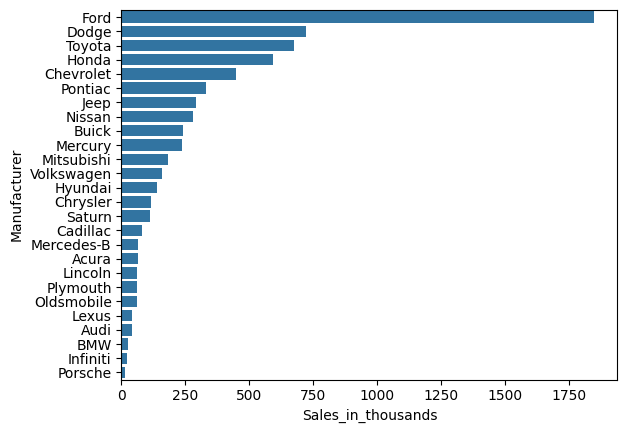

In [29]:
bar_data = cleaned_car_sales.groupby('Manufacturer')['Sales_in_thousands'].sum().reset_index().sort_values('Sales_in_thousands', ascending = False)
sns.barplot(x = 'Sales_in_thousands', y = 'Manufacturer', data = bar_data)

<Axes: xlabel='Vehicle_type', ylabel='Sales_in_thousands'>

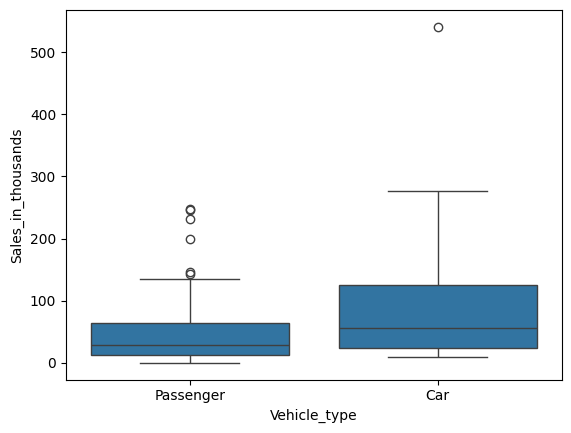

In [36]:
sns.boxplot(x = 'Vehicle_type', y = 'Sales_in_thousands', data = cleaned_car_sales)

<Axes: xlabel='Vehicle_type', ylabel='count'>

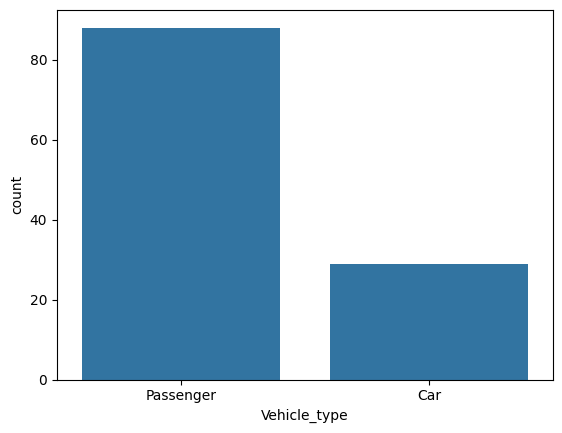

In [35]:
sns.countplot(x= cleaned_car_sales['Vehicle_type'])

<Axes: xlabel='Latest_Launch', ylabel='Sales_in_thousands'>

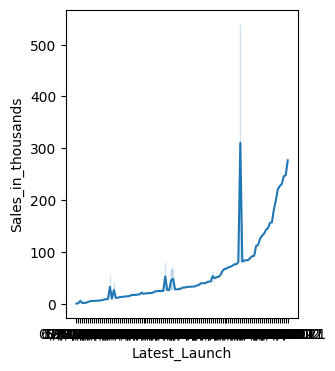

In [39]:
### Line Plot
import matplotlib.pyplot as plt
plt.figure(figsize = (3, 4))
sns.lineplot(x = 'Latest_Launch', y = 'Sales_in_thousands', data = cleaned_car_sales)

<Axes: xlabel='Sales_in_thousands', ylabel='Price_in_thousands'>

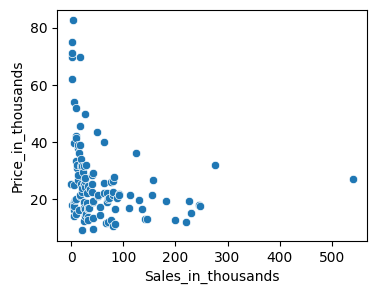

In [41]:
plt.figure(figsize = (4, 3))
sns.scatterplot(x = 'Sales_in_thousands', y = 'Price_in_thousands', data = cleaned_car_sales)

np.float64(1.944909826270953)

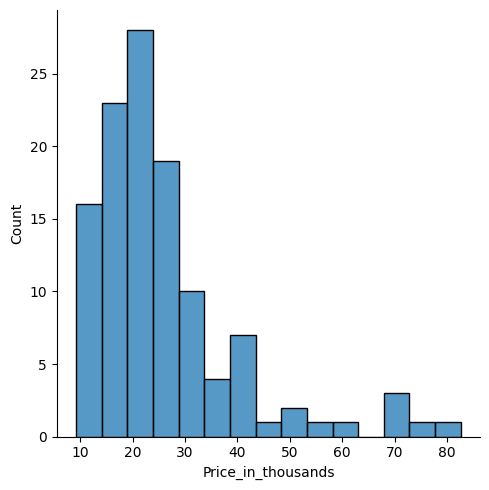

In [44]:
sns.displot(x = cleaned_car_sales['Price_in_thousands'])
cleaned_car_sales['Price_in_thousands'].skew()

<Axes: xlabel='Sales_in_thousands', ylabel='Price_in_thousands'>

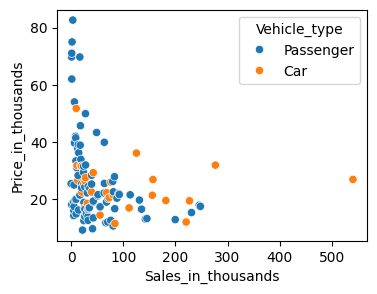

In [43]:
plt.figure(figsize = (4, 3))
sns.scatterplot(x = 'Sales_in_thousands', y = 'Price_in_thousands',hue = 'Vehicle_type', data = cleaned_car_sales)

<Axes: xlabel='Sales_in_thousands', ylabel='Manufacturer'>

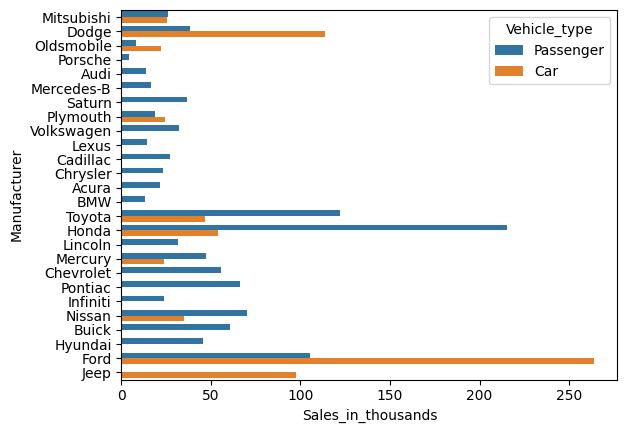

In [45]:
sns.barplot(y = 'Manufacturer', x = 'Sales_in_thousands', hue = 'Vehicle_type', data = cleaned_car_sales,errorbar = None)

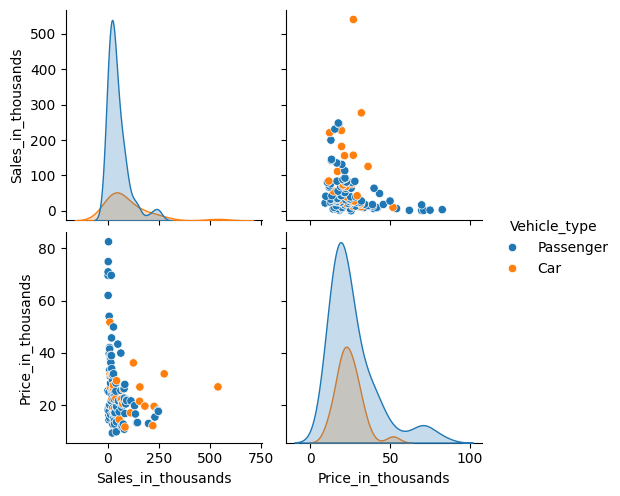

In [51]:
sns.pairplot(data = cleaned_car_sales[['Sales_in_thousands','Price_in_thousands','Vehicle_type']], hue = 'Vehicle_type')